# Модели AR, MA и ARMA. Модель ARIMA и её вариации. Критерии информационной оценки моделей: AIC и BIC

## 1. Модели AR, MA и ARMA

### 1.1 Модель авторегрессии (AR)

**Определение:**

Модель авторегрессии порядка \( p \) (AR\( p \)) выражает текущее значение временного ряда как линейную комбинацию \( p \) предыдущих значений и случайной ошибки.

**Математическая формулировка:**

$$
y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t
$$

где:
- $( y_t )$ — значение временного ряда в момент времени $( t )$;
- $( \phi_i )$ — параметры модели;
- $( \varepsilon_t )$ — белый шум (случайная ошибка с нулевым средним и постоянной дисперсией).

**Свойства:**

- Стационарность: Для стационарности модели корни характеристического уравнения должны лежать вне единичного круга.
- Автокорреляционная функция (ACF) убывает экспоненциально или колеблется.
- Частичная автокорреляционная функция (PACF) обрывается после лага $( p $).

**Оценка параметров:**

- Метод наименьших квадратов (МНК).
- Метод максимально правдоподобия.

---

#### Обучение модели AR

Обучение модели AR заключается в нахождении параметров $\phi_1, \phi_2, \dots, \phi_p$, которые минимизируют ошибку между реальными значениями $y_t$ и предсказанными значениями $\hat{y}_t$. Мы используем метод наименьших квадратов (МНК) для подбора параметров.

Ошибка модели определяется как:

$$
e_t = y_t - \hat{y}_t
$$

Где $\hat{y}_t$ — это предсказанное значение временного ряда:

$$
\hat{y}_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p}
$$

Задача заключается в минимизации суммы квадратов ошибок:

$$
\min_{\phi_1, \dots, \phi_p} \sum_{t=p+1}^{T} e_t^2 = \sum_{t=p+1}^{T} \left(y_t - \left( \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} \right) \right)^2
$$

Чтобы найти параметры $\phi_1, \dots, \phi_p$, нужно решить следующую систему уравнений:

$$
X \Phi = Y
$$

$$
X^T X \Phi = X^T Y
$$

где:
- $X$ — матрица предыдущих значений ряда:
$$
X = \begin{pmatrix}
y_{p} & y_{p-1} & \dots & y_1 \\
y_{p+1} & y_{p} & \dots & y_2 \\
\vdots & \vdots & \ddots & \vdots \\
y_{T-1} & y_{T-2} & \dots & y_{T-p}
\end{pmatrix}
$$

- $Y$ — вектор целевых значений:
$$
Y = \begin{pmatrix}
y_{p+1} \\
y_{p+2} \\
\vdots \\
y_{T}
\end{pmatrix}
$$

- $\Phi$ — вектор параметров:
$$
\Phi = \begin{pmatrix}
\phi_1 \\
\phi_2 \\
\vdots \\
\phi_p
\end{pmatrix}
$$

После решения этого уравнения мы находим оптимальные параметры $\phi_1, \phi_2, \dots, \phi_p$.

---

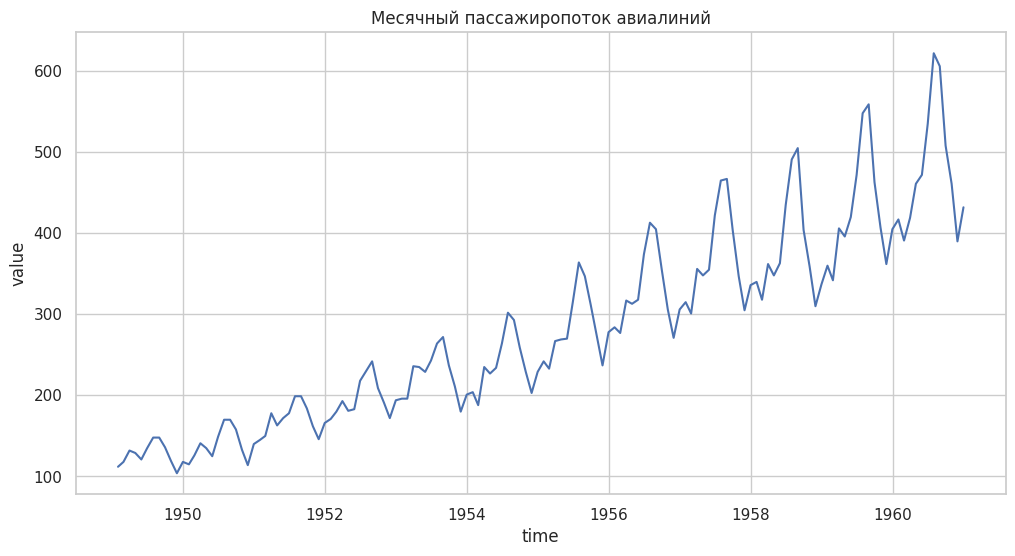

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings('ignore')

# Загрузим данные о месячном пассажиропотоке авиалиний
from statsmodels.datasets import get_rdataset
data = get_rdataset("AirPassengers").data
data['time'] = pd.date_range(start='1949-01', periods=len(data), freq='M')
data.set_index('time', inplace=True)
y = data['value']

sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y)
plt.title('Месячный пассажиропоток авиалиний')
plt.show()

In [ ]:
data.head()

,value
time,
1949-01-31,112
1949-02-28,118
1949-03-31,132
1949-04-30,129
1949-05-31,121


                            AutoReg Model Results                             
Dep. Variable:                  value   No. Observations:                  144
Model:                     AutoReg(2)   Log Likelihood                -691.539
Method:               Conditional MLE   S.D. of innovations             31.534
Date:                Wed, 25 Feb 2026   AIC                           1391.079
Time:                        07:52:30   BIC                           1402.902
Sample:                    03-31-1949   HQIC                          1395.883
                         - 12-31-1960                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.4821      6.811      2.420      0.016       3.134      29.831
value.L1       1.2766      0.080     16.009      0.000       1.120       1.433
value.L2      -0.3298      0.079     -4.152      0.0

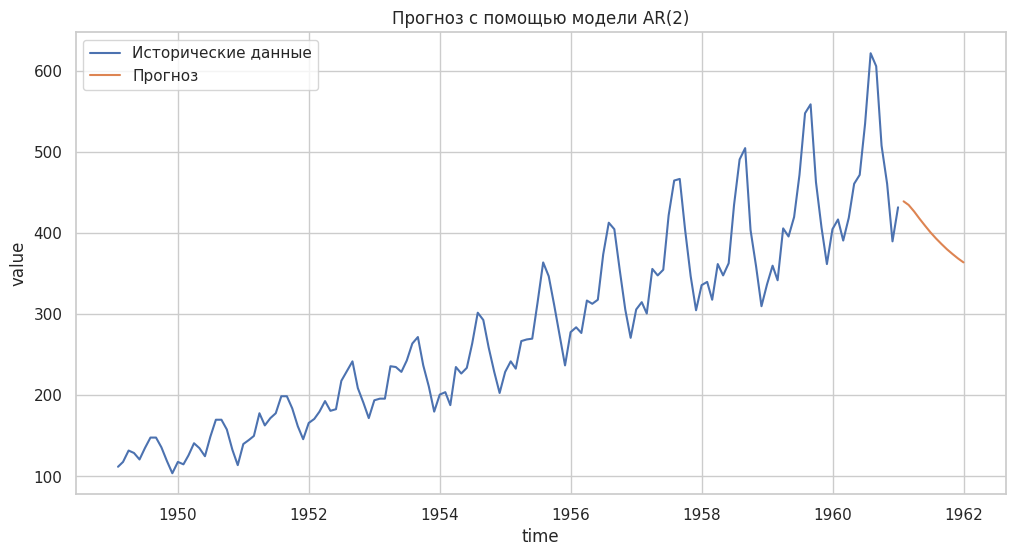

In [ ]:
# AR(2)
model = AutoReg(y, lags=2).fit()
print(model.summary())

# Прогноз на 12 месяцев вперед
forecast = model.predict(start=len(y), end=len(y)+11)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast, label='Прогноз')
plt.title('Прогноз с помощью модели AR(2)')
plt.show()

value(t) = 16.48 + 1.28×value(t-1) - 0.33×value(t-2)

# Корни в авторегрессионных (AR) моделях

## 1. Что такое характеристическое уравнение?

Для AR(p) модели вида:

$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + ... + \phi_p X_{t-p} + \varepsilon_t$$

**Характеристическое уравнение** записывается как:

$$1 - \phi_1 z - \phi_2 z^2 - ... - \phi_p z^p = 0$$

или в операторной форме:

$$\Phi(z) = 1 - \sum_{i=1}^{p} \phi_i z^i = 0$$

## 2. Что такое корни?

**Корни** — это значения $z$, при которых характеристический полином обращается в ноль.

Для AR(2) модели:
$$1 - \phi_1 z - \phi_2 z^2 = 0$$

Это квадратное уравнение, которое имеет **два корня** $z_1$ и $z_2$.

## 3. Условие стационарности

### Основное правило:

> **AR(p) модель стационарна тогда и только тогда, когда все корни характеристического уравнения лежат **вне единичного круга** на комплексной плоскости.**

Математически:
$$|z_i| > 1 \quad \text{для всех } i = 1, 2, ..., p$$


## 4. Интерпретация корней

### Модуль корня ($|z|$):
- Определяет **скорость затухания** влияния шоков
- Чем больше модуль, тем быстрее процесс возвращается к среднему
- Если $|z| \approx 1$ (близко к границе), процесс имеет **долгую память**

### Частота корня:
- Определяет **цикличность** процесса
- Если корень комплексный ($a + bi$), процесс будет иметь колебательную компоненту
- Частота вычисляется как: $f = \frac{\arctan(b/a)}{2\pi}$

## 5. Связь корней с поведением процесса

| Расположение корней | Поведение процесса |
|---------------------|-------------------|
| Вещественные, $|z| > 1$ | Монотонное затухание |
| Комплексные, $|z| > 1$ | Затухающие колебания |
| $|z| \approx 1$ | Медленное затухание (долгая память) |
| $|z| = 1$ | Единичный корень (нестационарен) |
| $|z| < 1$ | Взрывной процесс (нестационарен) |

## 6. Практическое значение

1. **Проверка адекватности модели** — если корни внутри единичного круга, модель не подходит
2. **Прогнозирование** — стационарные модели дают надежные долгосрочные прогнозы
3. **Интерпретация** — корни показывают, как быстро процесс забывает прошлые шоки


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Применим тест Дики-Фуллера
result = adfuller(y)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: 0.815369
p-value: 0.991880


ADF Statistic (дифференцированный ряд): -2.829267
p-value: 0.054213


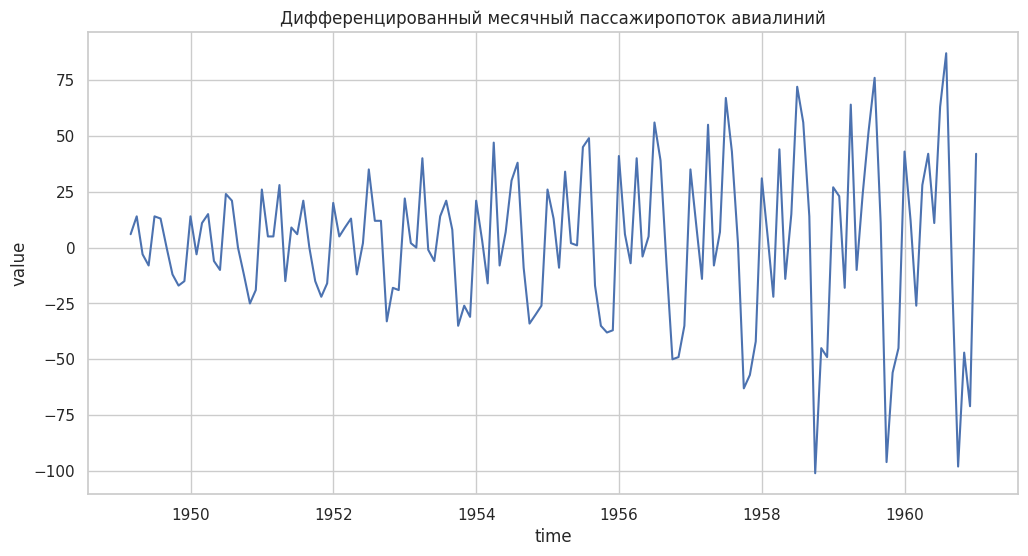

In [ ]:
y_diff = y.diff().dropna()

#тест Дики-Фуллера на дифференцированном ряде
result_diff = adfuller(y_diff)
print('ADF Statistic (дифференцированный ряд): %f' % result_diff[0])
print('p-value: %f' % result_diff[1])

plt.figure(figsize=(12, 6))
sns.lineplot(data=y_diff)
plt.title('Дифференцированный месячный пассажиропоток авиалиний')
plt.show()

ADF Statistic (дифференцированный ряд): -16.384232
p-value: 0.000000


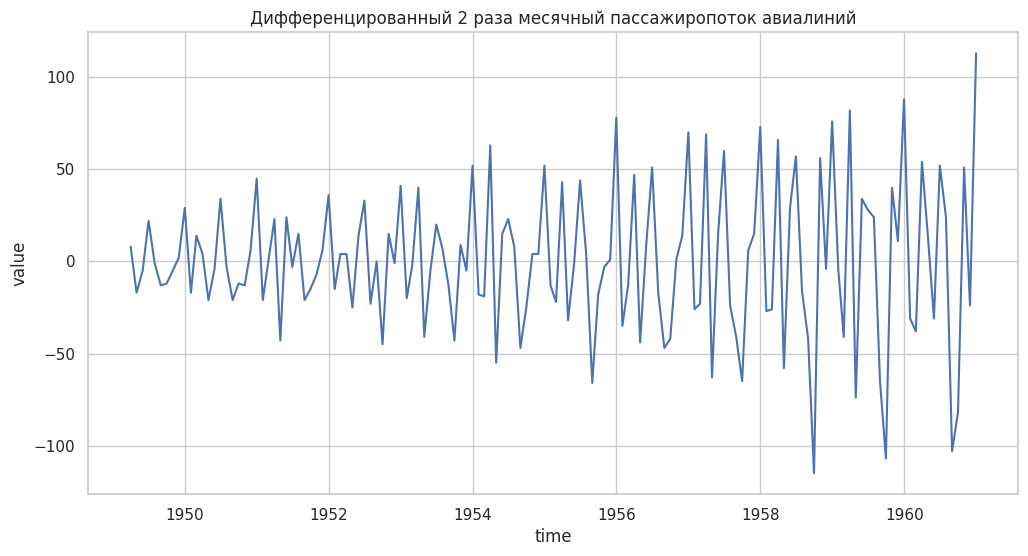

In [ ]:
y_diff2 = y_diff.diff().dropna()

#тест Дики-Фуллера
result_diff = adfuller(y_diff2)
print('ADF Statistic (дифференцированный ряд): %f' % result_diff[0])
print('p-value: %f' % result_diff[1])

plt.figure(figsize=(12, 6))
sns.lineplot(data=y_diff2)
plt.title('Дифференцированный 2 раза месячный пассажиропоток авиалиний')
plt.show()

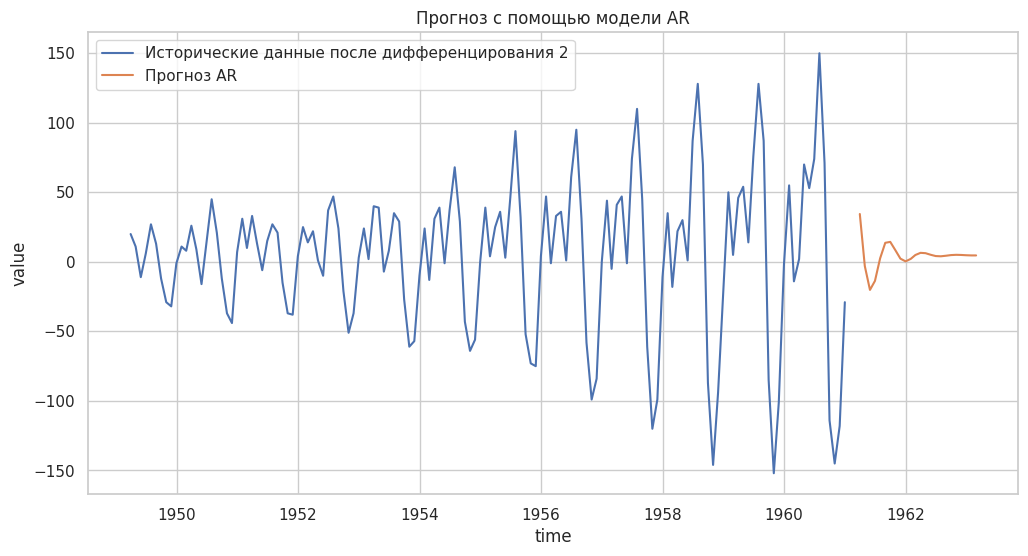

In [ ]:
model_ar = AutoReg(y.diff(2).dropna(), lags=2).fit()

# Прогноз на 24 месяцев вперед
model_ar = model_ar.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y.diff(2), label='Исторические данные после дифференцирования 2')
sns.lineplot(data=model_ar, label='Прогноз AR')
plt.title('Прогноз с помощью модели AR')
plt.show()

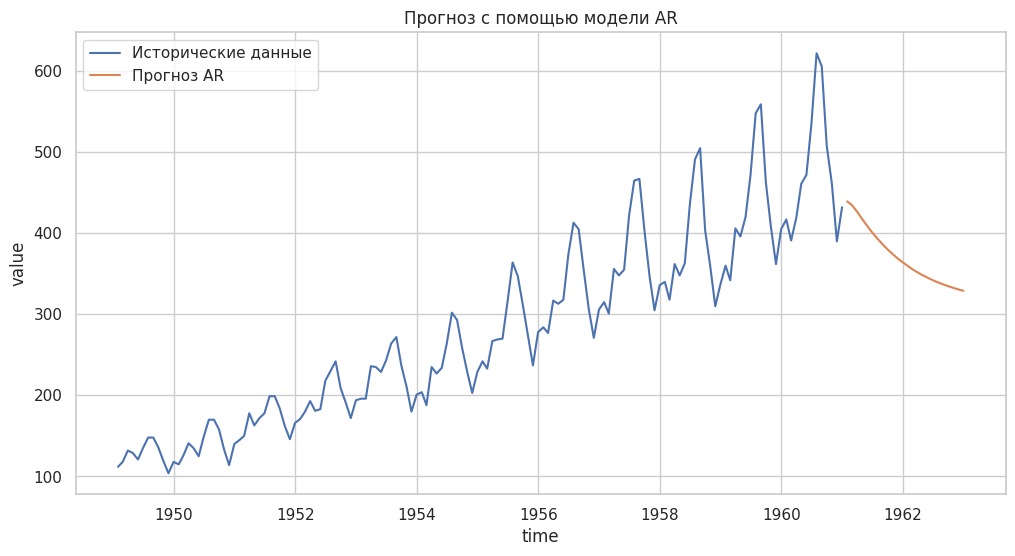

In [ ]:
model_ar = AutoReg(y, lags=2).fit()

# Прогноз на 24 месяцев вперед
model_ar = model_ar.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=model_ar, label='Прогноз AR')
plt.title('Прогноз с помощью модели AR')
plt.show()

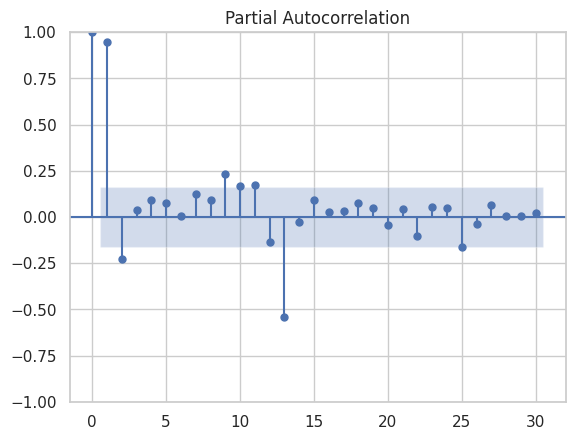

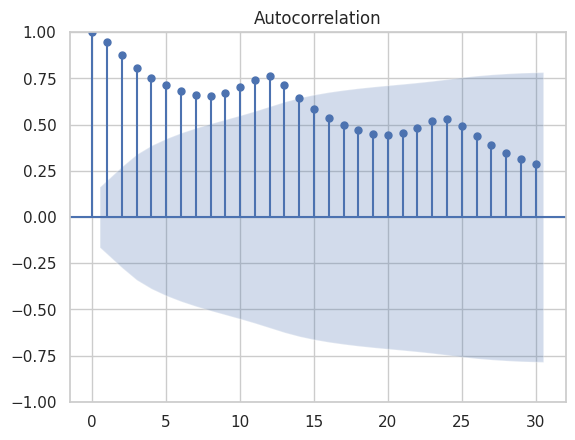

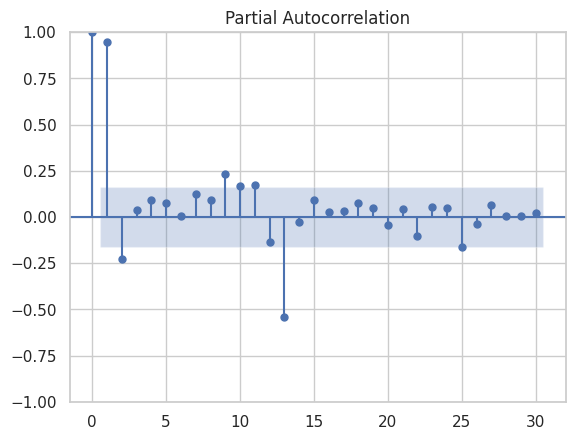

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(y, lags=30)
plot_pacf(y, lags=30)

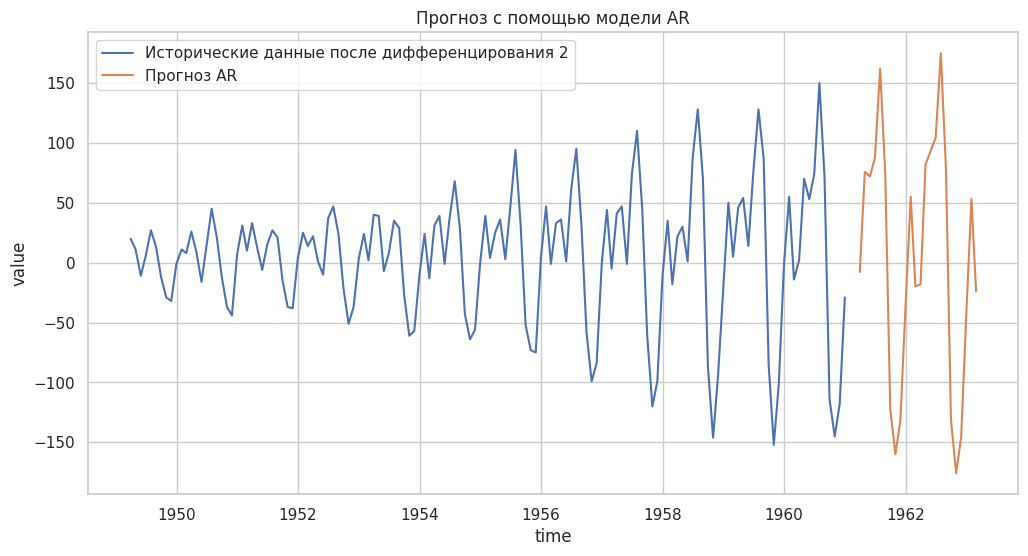

In [ ]:
model_ar = AutoReg(y.diff(2).dropna(), lags=13).fit()

# Прогноз на 24 месяцев вперед
model_ar = model_ar.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y.diff(2), label='Исторические данные после дифференцирования 2')
sns.lineplot(data=model_ar, label='Прогноз AR')
plt.title('Прогноз с помощью модели AR')
plt.show()

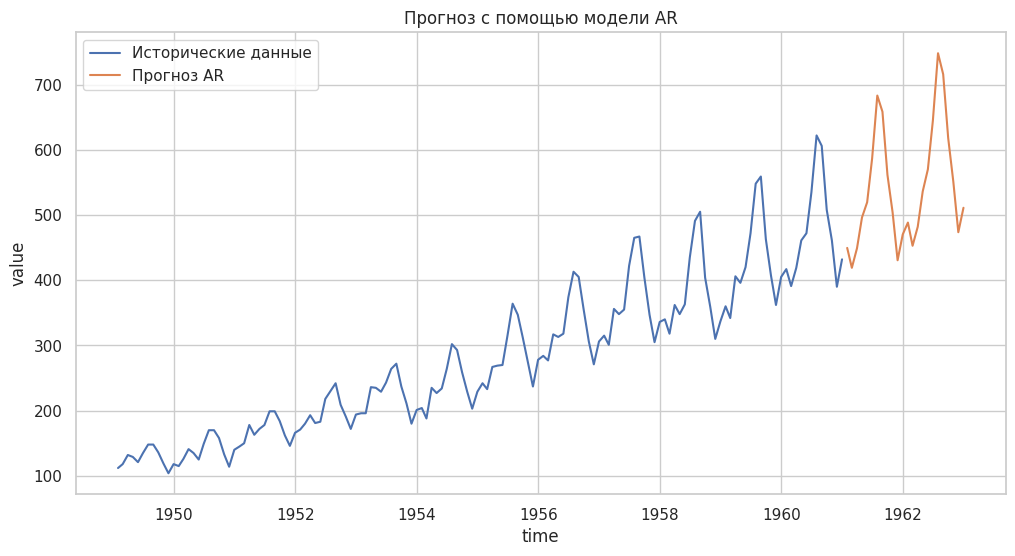

In [ ]:
model_ar = AutoReg(y, lags=13).fit()

# Прогноз на 24 месяца вперед
model_ar = model_ar.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=model_ar, label='Прогноз AR')
plt.title('Прогноз с помощью модели AR')
plt.show()

### 1.2 Модель скользящего среднего (MA)

**Определение:**

Модель скользящего среднего порядка $q$ (MA($q$)) выражает текущее значение временного ряда как линейную комбинацию текущей и $q$ предыдущих случайных ошибок.

**Математическая формулировка:**

$$
y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}
$$

где:

- $\mu$ — среднее значение ряда;
- $\theta_i$ — параметры модели;
- $\varepsilon_t$ — белый шум.

**Свойства:**

- **Стационарность:** Модель всегда стационарна при любых значениях параметров.
- **ACF:** Автокорреляционная функция обрывается после лага $q$.
- **PACF:** Частичная автокорреляционная функция убывает экспоненциально или колеблется.

**Оценка параметров:**

- Метод максимально правдоподобия.
- Нелинейные методы оптимизации.
---

#### Обучение модели MA

В случае модели скользящего среднего (MA) задача заключается в нахождении параметров $\theta_1, \dots, \theta_q$. В отличие от модели AR, которая использует предыдущие значения временного ряда, модель MA использует предыдущие ошибки (остатки).

Ошибка предсказания определяется как:

$$
e_t = y_t - \hat{y}_t
$$

где предсказанное значение временного ряда:

$$
\hat{y}_t = \mu + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}
$$

Задача состоит в минимизации функции правдоподобия для белого шума $\varepsilon_t$. Метод наименьших квадратов неприменим для MA моделей из-за зависимости ошибок от параметров модели, поэтому используются численные методы оптимизации, такие как метод Ньютона-Рафсона.

Функция правдоподобия:

$$
L(\theta_1, \dots, \theta_q) = \prod_{t=1}^{T} \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left( -\frac{(y_t - \hat{y}_t)^2}{2 \sigma^2} \right)
$$

Максимизируя эту функцию, мы находим параметры $\theta_1, \theta_2, \dots, \theta_q$.

---

**Подходит для рядов, где:**
1. Шоки имеют временный эффект

    1.1. Продажи после рекламной акции

    1.2. Спрос после праздников

    1.3. Реакция на новости
2. "Эхо" от событий затухает быстро

    2.1. Ошибки прогноза

    2.2. Краткосрочные возмущения
3. Сглаживание случайных колебаний

    3.1. Данные с шумом измерений

    3.2. Сглаженные индексы

Для программного запуска шажок вперед:

**from statsmodels.tsa.arima.model import ARIMA**

ARIMA(data, order=(p, d, q))

        order = (p, d, q)
                 │  │  │
                 │  │  └─→ MA часть (лаги ошибок)
                 │  └────→ Интеграция (разности)
                 └───────→ AR часть (лаги ряда)

Примеры:
* (1, 0, 0) → AR(1)           [только AR]
* (0, 0, 1) → MA(1)           [только MA]
* (1, 0, 1) → ARMA(1,1)       [AR + MA]
* (1, 1, 1) → ARIMA(1,1,1)    [AR + I + MA]
* (0, 0, 0) → Белый шум       [ничего]

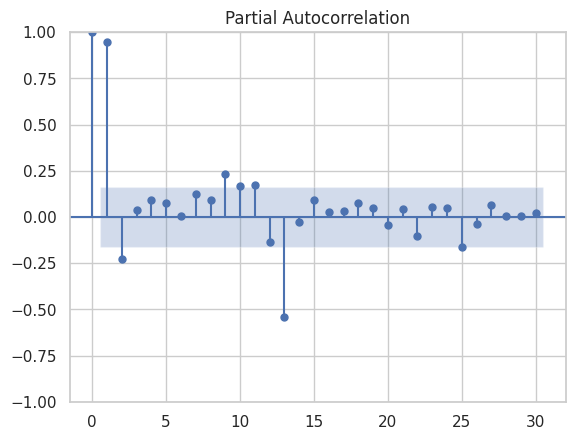

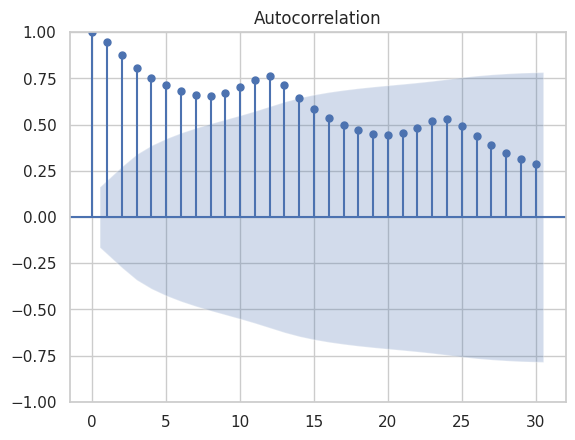

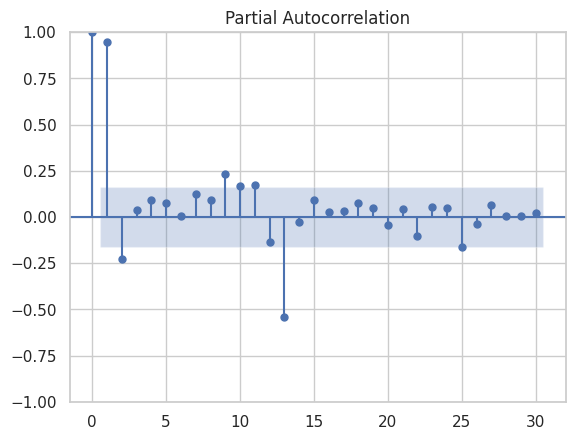

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(y, lags=30)
plot_pacf(y, lags=30)

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                 ARIMA(0, 0, 3)   Log Likelihood                -725.681
Date:                Wed, 25 Feb 2026   AIC                           1461.362
Time:                        15:56:30   BIC                           1476.211
Sample:                    01-31-1949   HQIC                          1467.396
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.2934     16.609     16.876      0.000     247.741     312.846
ma.L1          1.4274    121.637      0.012      0.991    -236.977     239.831
ma.L2          1.4272     52.343      0.027      0.9

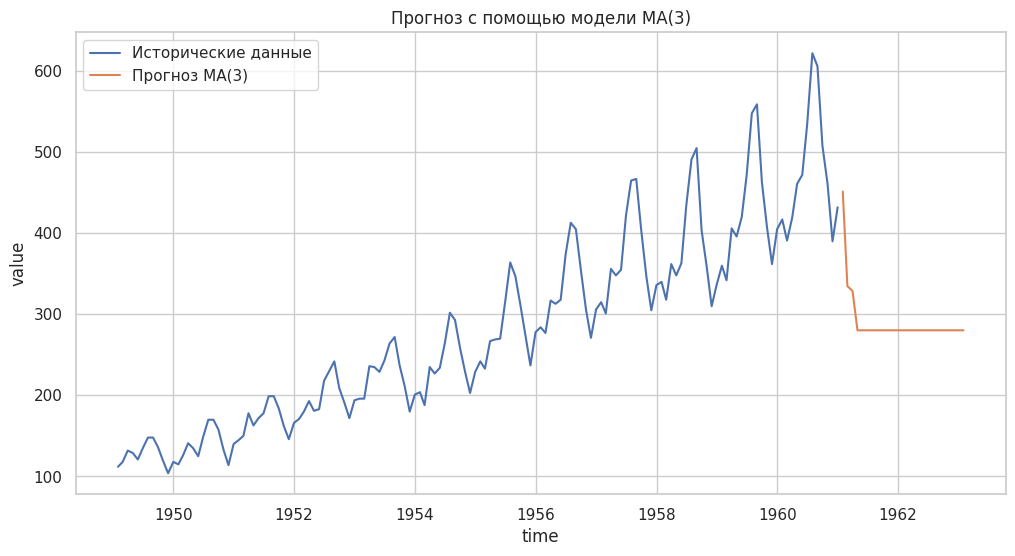

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Применим модель MA(3)
model_ma = ARIMA(y, order=(0, 0, 3)).fit()
print(model_ma.summary())

# Прогноз на 24 месяца вперед
forecast_ma = model_ma.predict(start=len(y), end=len(y)+24)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_ma, label='Прогноз MA(3)')
plt.title('Прогноз с помощью модели MA(3)')
plt.show()

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                ARIMA(0, 0, 13)   Log Likelihood                -672.574
Date:                Wed, 25 Feb 2026   AIC                           1375.148
Time:                        08:57:45   BIC                           1419.695
Sample:                    01-31-1949   HQIC                          1393.249
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.2901     20.885     13.421      0.000     239.357     321.223
ma.L1          1.3133    114.299      0.011      0.991    -222.708     225.335
ma.L2          1.0534     90.790      0.012      0.9

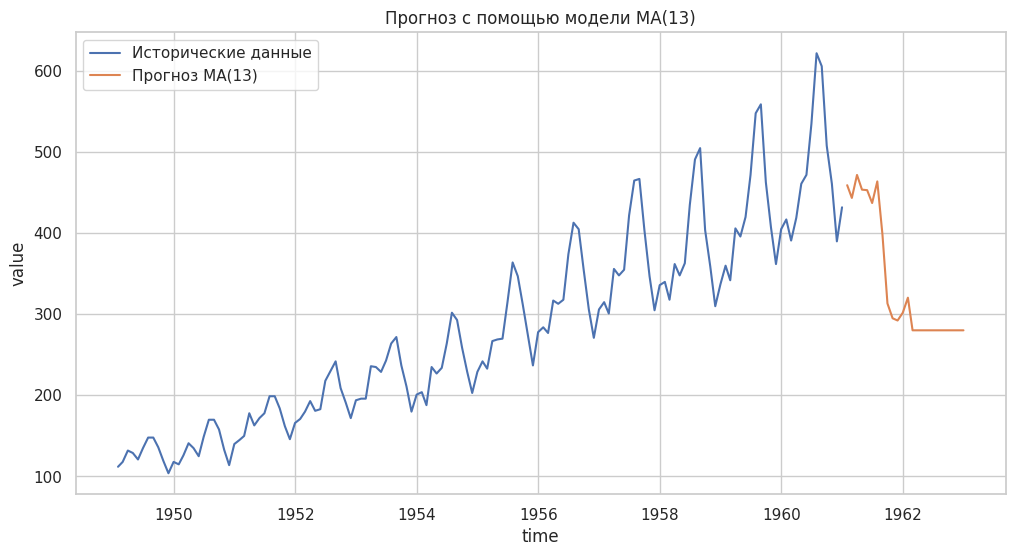

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Применим модель MA(13)
model_ma = ARIMA(y, order=(0, 0, 13)).fit()
print(model_ma.summary())

# Прогноз на 24 месяца вперед
forecast_ma = model_ma.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_ma, label='Прогноз MA(13)')
plt.title('Прогноз с помощью модели MA(13)')
plt.show()

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                ARIMA(0, 0, 13)   Log Likelihood                -632.765
Date:                Wed, 25 Feb 2026   AIC                           1295.531
Time:                        09:03:43   BIC                           1339.868
Sample:                    03-31-1949   HQIC                          1313.548
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5950      0.694      8.060      0.000       4.234       6.955
ma.L1          1.1505      3.900      0.295      0.768      -6.493       8.794
ma.L2         -0.1671      4.320     -0.039      0.9

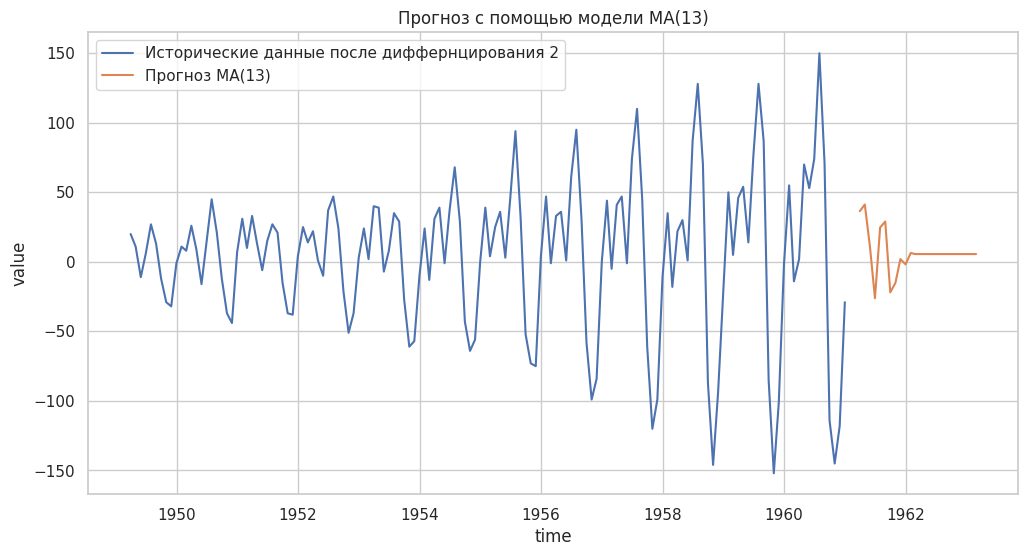

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Применим модель MA(13)
model_ma = ARIMA(y.diff(2).dropna(), order=(0, 0, 13)).fit()
print(model_ma.summary())

# Прогноз на 24 месяца вперед
forecast_ma = model_ma.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y.diff(2), label='Исторические данные после диффернцирования 2')
sns.lineplot(data=forecast_ma, label='Прогноз MA(13)')
plt.title('Прогноз с помощью модели MA(13)')
plt.show()

### 1.3 Модель ARMA

**Определение:**

Модель ARMA сочетает в себе авторегрессионную часть и часть скользящего среднего.

**Математическая формулировка:**

$$
y_t = \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
$$

**Свойства:**

- Объединяет свойства моделей AR и MA.
- Используется для стационарных временных рядов.
---

#### Обучение модели ARMA

Обучение модели ARMA заключается в нахождении параметров $\phi_1, \dots, \phi_p, \theta_1, \dots, \theta_q$, которые минимизируют разницу между фактическими и предсказанными значениями временного ряда.

Задача обучения модели ARMA аналогична обучению моделей AR и MA. Для нахождения параметров используется максимизация функции правдоподобия.

Функция правдоподобия:

$$
L(\phi_1, \dots, \phi_p, \theta_1, \dots, \theta_q) = \prod_{t=1}^{T} \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left( -\frac{(y_t - \hat{y}_t)^2}{2 \sigma^2} \right)
$$

где $\hat{y}_t$ — это предсказанное значение:

$$
\hat{y}_t = \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
$$

Максимизируя эту функцию правдоподобия, мы находим параметры $\phi_1, \dots, \phi_p, \theta_1, \dots, \theta_q$. В реальных задачах для решения этой задачи используются численные методы оптимизации, такие как метод Ньютона или алгоритмы градиентного спуска.

---

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:               ARIMA(13, 0, 13)   Log Likelihood                -548.032
Date:                Wed, 25 Feb 2026   AIC                           1152.065
Time:                        09:05:20   BIC                           1234.828
Sample:                    03-31-1949   HQIC                          1185.696
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3482      1.074      4.047      0.000       2.243       6.454
ar.L1          0.1324      7.173      0.018      0.985     -13.927      14.192
ar.L2         -0.3327      6.212     -0.054      0.9

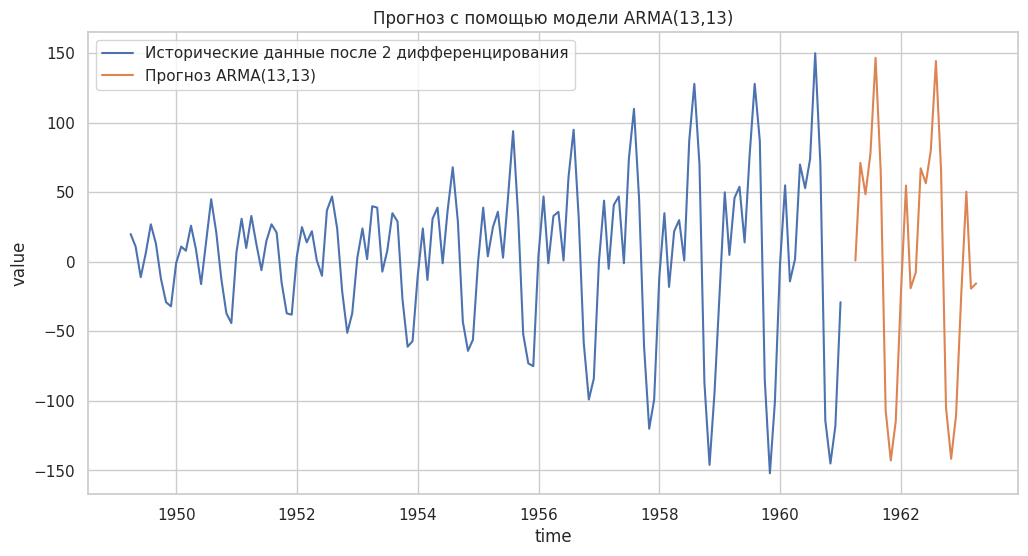

In [ ]:
model_arma = ARIMA(y.diff(2).dropna(), order=(13, 0, 13)).fit()
print(model_arma.summary())

# Прогноз на 24 месяца вперед
forecast_arma = model_arma.predict(start=len(y), end=len(y)+24)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y.diff(2), label='Исторические данные после 2 дифференцирования')
sns.lineplot(data=forecast_arma, label='Прогноз ARMA(13,13)')
plt.title('Прогноз с помощью модели ARMA(13,13)')
plt.show()

## 2. Модель ARIMA и её вариации

### 2.1 Модель ARIMA

**Определение:**

Модель ARIMA ($p$, $d$, $q$) расширяет ARMA, включив оператор интегрирования, чтобы справляться с нестационарными рядами.

**Математическая формулировка:**

$$
\Delta^d y_t = \phi_1 \Delta^d y_{t-1} + \dots + \phi_p \Delta^d y_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
$$

где $\Delta^d$ — оператор разности порядка $d$.


Модель ARIMA состоит из трёх компонентов:

1. **Автокорреляционная часть (AR($p$))**
2. **Интегрированная часть (I($d$))**
3. **Скользящее среднее (MA($q$))**

Общая формула модели ARIMA($p$, $d$, $q$):

$$
\phi(B) \Delta^d y_t = \theta(B) \varepsilon_t
$$

где:

- $\phi(B)$ — оператор авторегрессии порядка $p$:

$$
\phi(B) = 1 - \phi_1 B - \phi_2 B^2 - \dots - \phi_p B^p
$$

- $\theta(B)$ — оператор скользящего среднего порядка $q$:

$$
\theta(B) = 1 + \theta_1 B + \theta_2 B^2 + \dots + \theta_q B^q
$$

- $B$ — оператор сдвига (лаговый оператор), такой что $B y_t = y_{t-1}$;
- $\Delta^d$ — оператор разности порядка $d$:

$$
\Delta^d y_t = (1 - B)^d y_t
$$

- $\varepsilon_t$ — белый шум с нулевым средним и постоянной дисперсией.

---

#### Обучение модели ARIMA

Обучение модели ARIMA заключается в оценке параметров $\phi_1, \dots, \phi_p$, $\theta_1, \dots, \theta_q$ и $d$, которые наилучшим образом описывают динамику временного ряда.

##### Шаг 1: Приведение ряда к стационарному виду

- **Дифференцирование ряда**

Чтобы добиться стационарности, применяем оператор разности порядка $d$:

$$
w_t = \Delta^d y_t = (1 - B)^d y_t
$$

Например, при $d=1$:

$$
w_t = y_t - y_{t-1}
$$

Проверяем стационарность полученного ряда $w_t$ с помощью тестов, таких как тест Дики-Фуллера.

##### Шаг 2: Идентификация параметров $p$ и $q$

- **Анализ ACF и PACF**

Используем автокорреляционную функцию (ACF) и частичную автокорреляционную функцию (PACF) для определения порядков $p$ и $q$.

##### Шаг 3: Оценка параметров модели

- **Метод максимального правдоподобия**

Функция правдоподобия для модели ARIMA определяется как:

$$
L(\Phi, \Theta | w_t) = \prod_{t=1}^{T} \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left( -\frac{(w_t - \hat{w}_t)^2}{2\sigma^2} \right)
$$

где:

- $\Phi = (\phi_1, \dots, \phi_p)$
- $\Theta = (\theta_1, \dots, \theta_q)$
- $\hat{w}_t$ — предсказанное значение стационарного ряда:

$$
\hat{w}_t = \phi_1 w_{t-1} + \dots + \phi_p w_{t-p} + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
$$

Задача состоит в максимизации логарифма функции правдоподобия:

$$
\ln L(\Phi, \Theta | w_t) = -\frac{T}{2} \ln(2\pi \sigma^2) - \frac{1}{2\sigma^2} \sum_{t=1}^{T} (w_t - \hat{w}_t)^2
$$

Путём взятия производных по параметрам и приравнивания их нулю получаем систему уравнений для $\Phi$ и $\Theta$. Решение этой системы обычно требует численных методов оптимизации из-за нелинейности уравнений.

##### Шаг 4: Диагностика модели

- **Анализ остатков**

Проверяем остатки модели на автокорреляцию, гомоскедастичность и нормальность распределения.

---

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:               ARIMA(13, 0, 13)   Log Likelihood                -608.168
Date:                Wed, 25 Feb 2026   AIC                           1272.335
Time:                        09:08:23   BIC                           1355.490
Sample:                    01-31-1949   HQIC                          1306.125
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.2963     66.572      4.210      0.000     149.817     410.775
ar.L1          0.7665      0.256      2.996      0.003       0.265       1.268
ar.L2         -0.0588      0.422     -0.139      0.8

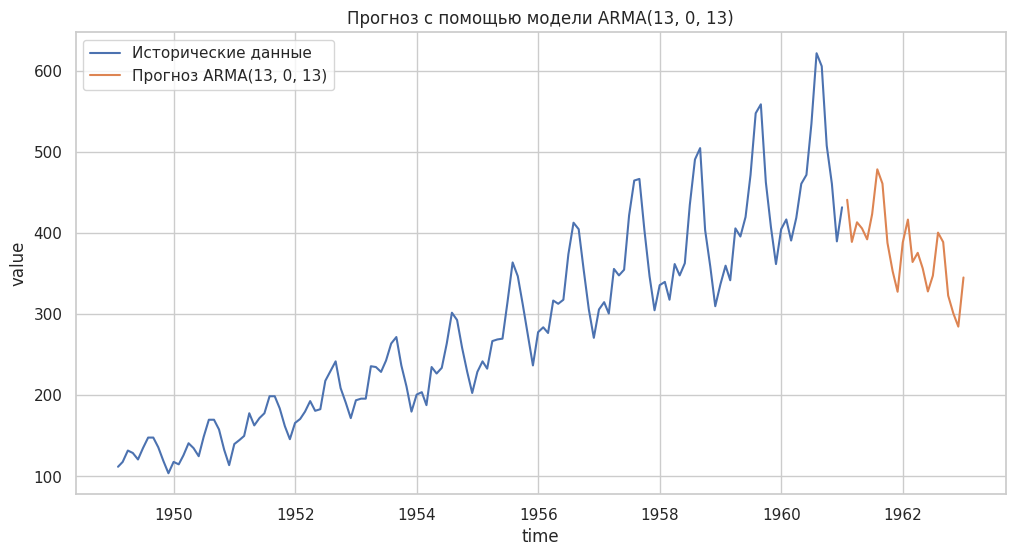

In [ ]:
model_arima = ARIMA(y, order=(13, 0, 13)).fit()
print(model_arima.summary())

# Прогноз на 24 месяца вперед
forecast_arima = model_arima.predict(start=len(y), end=len(y)+23, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_arima, label='Прогноз ARMA(13, 0, 13)')
plt.title('Прогноз с помощью модели ARMA(13, 0, 13)')
plt.show()

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:               ARIMA(13, 1, 13)   Log Likelihood                -551.474
Date:                Wed, 25 Feb 2026   AIC                           1156.948
Time:                        09:07:30   BIC                           1236.945
Sample:                    01-31-1949   HQIC                          1189.455
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1688      0.319      0.530      0.596      -0.456       0.793
ar.L2         -0.0952      0.192     -0.497      0.619      -0.471       0.280
ar.L3          0.0669      0.194      0.344      0.7

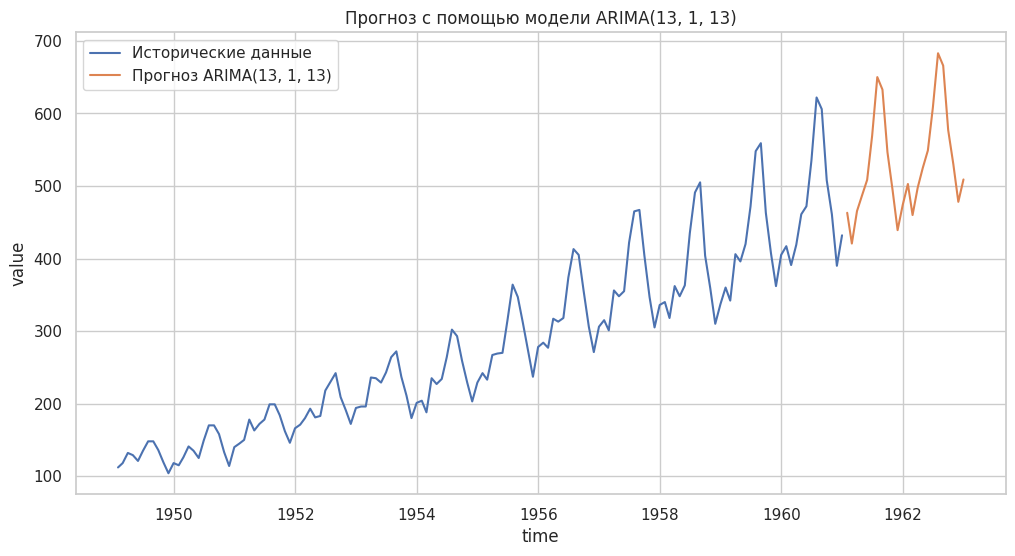

In [ ]:
model_arima = ARIMA(y, order=(13, 1, 13)).fit()
print(model_arima.summary())

# Прогноз на 24 месяца вперед
forecast_arima = model_arima.predict(start=len(y), end=len(y)+23, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(13, 1, 13)')
plt.title('Прогноз с помощью модели ARIMA(13, 1, 13)')
plt.show()

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:               ARIMA(13, 2, 13)   Log Likelihood                -555.420
Date:                Wed, 25 Feb 2026   AIC                           1164.840
Time:                        09:08:03   BIC                           1244.647
Sample:                    01-31-1949   HQIC                          1197.270
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5953      0.582     -1.022      0.307      -1.737       0.546
ar.L2         -0.1284      0.785     -0.164      0.870      -1.667       1.410
ar.L3         -0.1408      0.794     -0.177      0.8

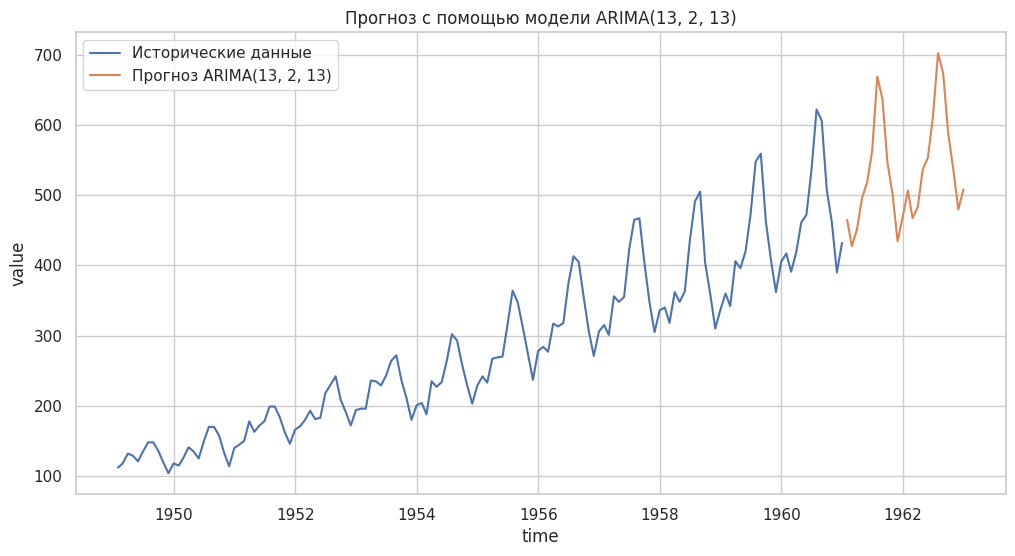

In [ ]:
model_arima = ARIMA(y, order=(13, 2, 13)).fit()
print(model_arima.summary())

# Прогноз на 24 месяца вперед
forecast_arima = model_arima.predict(start=len(y), end=len(y)+23, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(13, 2, 13)')
plt.title('Прогноз с помощью модели ARIMA(13, 2, 13)')
plt.show()

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 10.5 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

# auto_arima сам определит, сколько разностей нужно
model = auto_arima(
    y,
    start_p=0, max_p=13,
    start_q=0, max_q=13,
    d=None,              # ← Автоматический подбор!
    seasonal=False,
    trace=True,
    stepwise=True # перебор всех комбинаций
)

print(f"Оптимальный порядок: {model.order}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.58 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.55 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.44 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.43 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.30 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.54 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.78 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.23 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.21 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

ARIMA не учитывает сезонность!

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                 ARIMA(4, 2, 3)   Log Likelihood                -680.232
Date:                Thu, 24 Sep 2026   AIC                           1376.464
Time:                        16:39:34   BIC                           1400.111
Sample:                    01-31-1949   HQIC                          1386.074
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1639      0.094    -12.442      0.000      -1.347      -0.981
ar.L2         -0.4049      0.142     -2.844      0.004      -0.684      -0.126
ar.L3         -0.1055      0.125     -0.847      0.3

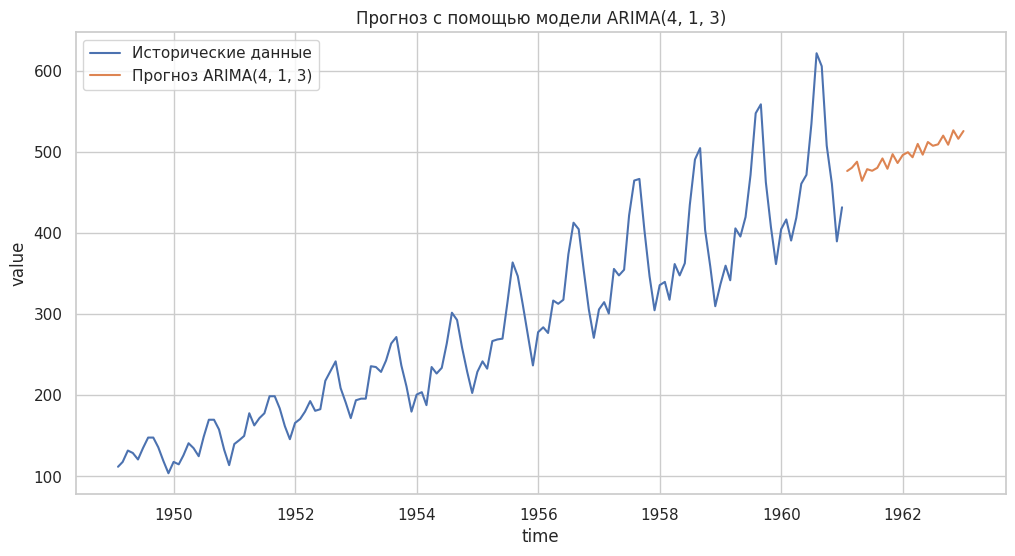

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(y, order=(4, 1, 3)).fit()
print(model_arima.summary())

# Прогноз на 24 месяца вперед
forecast_arima = model_arima.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(4, 1, 3)')
plt.title('Прогноз с помощью модели ARIMA(4, 1, 3)')
plt.show()

### 2.2 Сезонная модель ARIMA (SARIMA)

**Определение:**

Модель $SARIMA$ учитывает сезонность путем включения сезонных параметров.

**Математическая формулировка:**


Модель $SARIMA$ обозначается как $ARIMA(p, d, q)×(P, D, Q)_s$, где:

- $p$, $d$, $q$ — порядки обычных (несезонных) частей модели;
- $P$, $D$, $Q$ — порядки сезонных частей модели;
- $s$ — длина сезонности (например, $s=12$ для месячных данных с годовой сезонностью).

**Общая формула:**

$$
\Phi(B^s) \phi(B) \Delta^d \Delta_s^D y_t = \Theta(B^s) \theta(B) \varepsilon_t
$$

где:

- $\phi(B)$ — оператор авторегрессии порядка $p$;
- $\Phi(B^s)$ — оператор сезонной авторегрессии порядка $P$;
- $\theta(B)$ — оператор скользящего среднего порядка $q$;
- $\Theta(B^s)$ — оператор сезонного скользящего среднего порядка $Q$;
- $\Delta^d$ — оператор обычной разности порядка $d$;
- $\Delta_s^D$ — оператор сезонной разности порядка $D$:

$$
\Delta_s^D y_t = (1 - B^s)^D y_t
$$

---

#### Обучение модели SARIMA

Обучение модели SARIMA включает аналогичные шаги, как и для модели ARIMA, но с учётом сезонных компонентов.

##### Шаг 1: Приведение ряда к стационарному виду

- **Обычное дифференцирование:** применяем оператор разности $\Delta^d$
- **Сезонное дифференцирование:** применяем оператор сезонной разности $\Delta_s^D$

Получаем стационарный ряд:

$$
w_t = \Delta^d \Delta_s^D y_t
$$

##### Шаг 2: Идентификация параметров $p$, $q$, $P$, $Q$

- **Анализ ACF и PACF:**

  - **Несезонные лаги:** помогают определить $p$ и $q$.
  - **Сезонные лаги:** (кратные $s$) помогают определить $P$ и $Q$.

##### Шаг 3: Оценка параметров модели

- **Метод максимального правдоподобия**

Функция правдоподобия для модели SARIMA сложнее из-за сезонных компонентов, но общая идея остаётся той же. Оптимизация проводится по всем параметрам $\Phi$, $\phi$, $\Theta$, $\theta$ одновременно.

##### Шаг 4: Диагностика модели

- **Анализ остатков**

Проверяем остатки модели на автокорреляцию, особенно на сезонную автокорреляцию, гомоскедастичность и нормальность.

---

# Сравнение параметров SARIMA: `(p, d, q)` vs `(P, D, Q, s)`

| Критерий | Несезонные параметры `(p, d, q)` | Сезонные параметры `(P, D, Q, s)` |
|----------|----------------------------------|-----------------------------------|
| **Тип зависимости** | Краткосрочная, локальная (шаг $t-1, t-2...$) | Долгосрочная, циклическая (шаг $t-s, t-2s...$) |
| **Что моделирует** | Инерцию ряда, краткосрочные шоки, локальный тренд | Повторяющиеся паттерны, сезонные колебания |
| **Временной лаг** | 1 шаг назад = 1 период (вчера, последний час) | 1 шаг назад = $s$ периодов (год назад, неделя назад) |
| **$p$ / $P$ (AR)** | Влияние предыдущих **значений** ряда ($Y_{t-1}, Y_{t-2}$) | Влияние значений прошлого **сезона** ($Y_{t-s}, Y_{t-2s}$) |
| **$d$ / $D$ (I)** | Дифференцирование для удаления **глобального тренда** | Сезонное дифференцирование для удаления **сезонного тренда** |
| **$q$ / $Q$ (MA)** | Влияние предыдущих **ошибок прогноза** ($\varepsilon_{t-1}$) | Влияние ошибок прогноза прошлого **сезона** ($\varepsilon_{t-s}$) |
| **Диагностика (ACF)** | Затухание на первых лагах (1, 2, 3...) | Пики на лагах, кратных $s$ ($s, 2s, 3s...$) |
| **Диагностика (PACF)** | Значимые корреляции на первых лагах | Значимые корреляции на лагах $s, 2s...$ |
| **Типичные значения** | Чаще 0, 1, 2 (редко >3) | Чаще 0, 1 (иногда 2 при сложной сезонности) |
| **Когда ставить 0** | Если ряд стационарен и нет краткосрочной памяти | Если сезонность отсутствует или уже удалена другими методами |
| **Влияние на прогноз** | Определяет форму прогноза на **ближайшие шаги** | Определяет форму прогноза на **горизонте сезона** |
| **Пример для $s=12$** | $p=1$: январь зависит от декабря | $P=1$: январь зависит от января прошлого года |

---

## 🔍 Детальная расшифровка по компонентам

### Авторегрессия: $p$ vs $P$

| Ситуация | $p$ | $P$ | Объяснение |
|----------|-----|-----|------------|
| Продажи кофе | 1 | 0 | Вчерашние продажи влияют на сегодня, но год назад не релевантен |
| Электроэнергия | 1 | 1 | Влияет и вчерашний час, и тот же час вчера ($s=24$) |
| Новогодние продажи | 0 | 1 | Продажи зависят только от декабря прошлого года |

### Интегрирование: $d$ vs $D$

| Ситуация | $d$ | $D$ | Что делаем с данными |
|----------|-----|-----|---------------------|
| Растущий тренд + сезонность | 1 | 1 | $(1-B)(1-B^s)Y_t$ — убираем и тренд, и сезонность |
| Только сезонность, нет тренда | 0 | 1 | $(1-B^s)Y_t$ — сравниваем с тем же периодом прошлого года |
| Только тренд, нет сезонности | 1 | 0 | $(1-B)Y_t$ — работаем с разностями соседних значений |
| Стационарный ряд | 0 | 0 | Исходные данные, никаких преобразований |

> Где $B$ — оператор лага: $B Y_t = Y_{t-1}$, $B^s Y_t = Y_{t-s}$

### Скользящее среднее: $q$ vs $Q$


| Ситуация | $q$ | $Q$ | Объяснение |
|----------|-----|-----|------------|
| Случайный шум | 1 | 0 | Модель корректирует прогноз по вчерашней ошибке |
| Сезонные шоки | 0 | 1 | Ошибка в декабре прошлого года влияет на прогноз этого декабря |
| Сложная динамика | 1 | 1 | Учитываются и краткосрочные, и сезонные ошибки |

---

## Практические примеры комбинаций

### Пример 1: Ежедневные продажи ритейла ($s=7$)
```
SARIMAX(1, 1, 1)(1, 0, 1, 7)
```
| Параметр | Значение | Интерпретация |
|----------|----------|---------------|
| $p=1$ | ✅ | Продажи зависят от вчерашнего дня |
| $d=1$ | ✅ | Есть недельный тренд, который нужно убрать |
| $q=1$ | ✅ | Вчерашняя ошибка прогноза важна |
| $P=1$ | ✅ | Продажи в прошлый понедельник влияют на этот |
| $D=0$ | ✅ | Сезонный тренд стабилен, дифференцирование не нужно |
| $Q=1$ | ✅ | Ошибка прогноза неделю назад важна |
| $s=7$ | ✅ | Недельная сезонность |

### Пример 2: Месячные данные с годовой сезонностью ($s=12$)
```
SARIMAX(0, 1, 0)(0, 1, 1, 12)
```
| Параметр | Значение | Интерпретация |
|----------|----------|---------------|
| $p=0$ | ✅ | Нет краткосрочной авторегрессии |
| $d=1$ | ✅ | Есть долгосрочный тренд |
| $q=0$ | ✅ | Прошлые ошибки не влияют |
| $P=0$ | ✅ | Нет сезонной авторегрессии |
| $D=1$ | ✅ | Нужно убрать сезонность дифференцированием |
| $Q=1$ | ✅ | Ошибка декабря прошлого года влияет на прогноз |

---

## ⚠️ Частые ошибки и подводные камни

| Ошибка | Почему это плохо | Как исправить |
|--------|-----------------|---------------|
| **$P=p, D=d, Q=q$ по умолчанию** | Игнорирует разную природу зависимостей | Подбирать параметры независимо через AIC/BIC |
| **Слишком большие $p, q$** | Переобучение, нестабильные прогнозы | Начинать с малых значений (0, 1, 2) |
| **Неправильный $s$** | Сезонная часть не будет работать | Анализировать автокорреляцию и предметную область |
| **$D=1$ без необходимости** | Потеря информации, зашумленность ряда | Проверять стационарность сезонных разностей |
| **Игнорирование $d$ при тренде** | Нестационарность → ненадежные прогнозы | Всегда проверять ряд на стационарность (ADF-тест) |

---

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  144
Model:             SARIMAX(1, 2, 1)x(1, 1, 1, 12)   Log Likelihood                -505.608
Date:                            Thu, 24 Sep 2026   AIC                           1021.216
Time:                                    16:55:32   BIC                           1035.553
Sample:                                01-31-1949   HQIC                          1027.042
                                     - 12-31-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3177      0.092     -3.462      0.001      -0.498      -0.138
ma.L1         -0.9998      5.030   

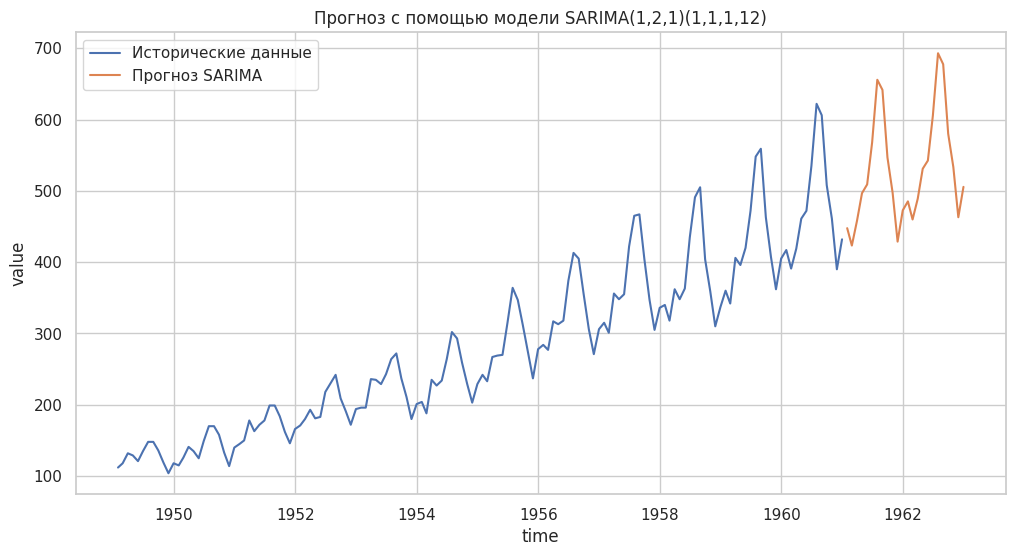

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(y, order=(1, 2, 1), seasonal_order=(1, 1, 1, 12)).fit()
print(model_sarima.summary())

# Прогноз на 24 месяца вперед
forecast_sarima = model_sarima.predict(start=len(y), end=len(y)+23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_sarima, label='Прогноз SARIMA')
plt.title('Прогноз с помощью модели SARIMA(1,2,1)(1,1,1,12)')
plt.show()

- **Сезонность:** параметры сезонности (1, 1, 1, 12) учитывают годовую сезонность данных.
- **Прогнозирование:** строим более длительный прогноз для оценки сезонных эффектов

#### Примечания по обучению моделей ARIMA и SARIMA

- **Численные методы оптимизации**

  Из-за сложности и нелинейности функции правдоподобия для моделей ARIMA и SARIMA используются численные методы оптимизации, такие как алгоритм Левенберга-Марквардта или BFGS.

- **Инициализация параметров**

  Хорошие начальные приближения параметров могут ускорить сходимость оптимизации. Часто используются методы на основе автокорреляционной функции.

- **Сезонность**

  При наличии сильной сезонности в данных модель SARIMA может значительно улучшить качество прогнозирования по сравнению с моделью ARIMA.

---


## Экзогенные переменные

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================
# СОЗДАНИЕ ЭКЗОГЕННЫХ ПЕРЕМЕННЫХ (НОВЫЙ ГОД)
# ============================================

def create_newyear_features(dates):
    """
    Создаёт признаки новогодних праздников (1-8 января)
    """
    df = pd.DataFrame(index=dates)

    # Новый Год: 1-8 января каждый год
    df['newyear'] = ((df.index.month == 1) & (df.index.day <= 8)).astype(int)

    # Предновогодняя неделя (25-31 декабря)
    df['pre_newyear'] = ((df.index.month == 12) & (df.index.day >= 25)).astype(int)

    return df

# Создаём экзогенные переменные для исторических данных
exog_history = create_newyear_features(y.index)

print("Пример экзогенных переменных:")
print(exog_history.head(15))
print("\nСтатистика по праздникам:")
print(exog_history.sum())

Пример экзогенных переменных:
            newyear  pre_newyear
time                            
1949-01-31        0            0
1949-02-28        0            0
1949-03-31        0            0
1949-04-30        0            0
1949-05-31        0            0
1949-06-30        0            0
1949-07-31        0            0
1949-08-31        0            0
1949-09-30        0            0
1949-10-31        0            0
1949-11-30        0            0
1949-12-31        0            1
1950-01-31        0            0
1950-02-28        0            0
1950-03-31        0            0

Статистика по праздникам:
newyear         0
pre_newyear    12
dtype: int64


In [ ]:
from pmdarima import auto_arima

# Автоматический поиск лучших параметров
model_auto = auto_arima(
    y,
    exogenous=exog_history,
    seasonal=True,
    m=12,  # или 365 для дневных данных
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"Лучшие параметры: {model_auto.order}{model_auto.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.75 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.12 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.46 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.16 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.49 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.08 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.17 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.40 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.41 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.81 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.05 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.05 sec
 ARIMA(3,1,1)(0,1,0


КОЭФФИЦИЕНТЫ МОДЕЛИ:
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
newyear              0         -0        nan        nan           0           0
pre_newyear    -0.0001   2.33e+05  -5.15e-10      1.000   -4.57e+05    4.57e+05
ar.L1           0.5959      0.086      6.958      0.000       0.428       0.764
ar.L2           0.2143      0.092      2.338      0.019       0.035       0.394
ma.L1          -0.9818      0.039    -25.369      0.000      -1.058      -0.906
sigma2        129.3089     14.699      8.797      0.000     100.500     158.117


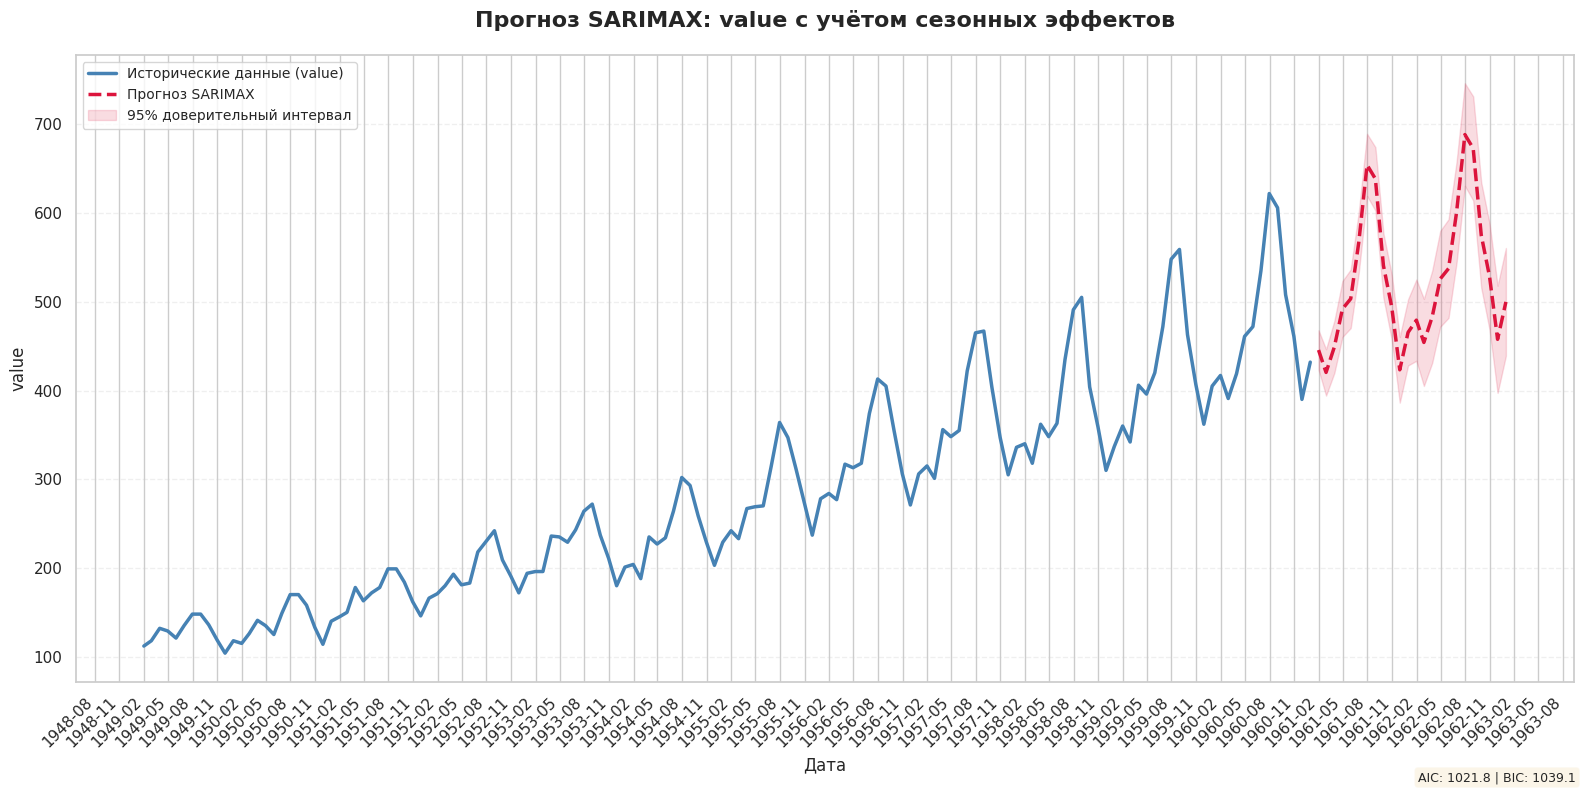

In [ ]:
# ============================================
# 3. ОБУЧЕНИЕ МОДЕЛИ SARIMAX
# ============================================

model_sarimax = SARIMAX(
    y,
    exog=exog_history,                    # ← Экзогенные переменные
    order=(2, 1, 1),
    seasonal_order=(0, 1, 0, 12)
).fit()

print("\n" + "="*50)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ:")
print("="*50)
print(model_sarimax.summary().tables[1])

# ============================================
# 4. ПРОГНОЗ НА 24 МЕСЯЦА ВПЕРЁД
# ============================================

# Создаём даты для прогноза
forecast_start = y.index[-1] + pd.Timedelta(days=1)
forecast_end = forecast_start + pd.Timedelta(days=730)  # 24 месяца ≈ 730 дней
forecast_dates = pd.date_range(start=forecast_start, end=forecast_end, freq='M')

# ⚠️ ВАЖНО: Нужно создать экзогенные переменные для будущего периода!
exog_future = create_newyear_features(forecast_dates)

# Делаем прогноз
forecast_sarimax = model_sarimax.predict(
    start=len(y),
    end=len(y) + len(forecast_dates) - 1,
    exog=exog_future,      # ← Экзогенные переменные для прогноза
)

# ============================================
# 5. ВИЗУАЛИЗАЦИЯ (адаптивная под y)
# ============================================

import matplotlib.dates as mdates

# Определяем подписи динамически
y_name = getattr(y, 'name', 'Целевая переменная') if hasattr(y, 'name') else 'Целевая переменная'
y_label = y_name if y_name else 'Значение'

# Получаем доверительные интервалы, если модель поддерживает
try:
    forecast_result = model_sarimax.get_forecast(
        steps=len(forecast_dates),
        exog=exog_future
    )
    forecast_mean = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int(alpha=0.05)  # 95% CI
    use_conf_int = True
except:
    forecast_mean = forecast_sarimax
    use_conf_int = False

plt.figure(figsize=(16, 8))

# Исторические данные
sns.lineplot(x=y.index, y=y.values, label=f'Исторические данные ({y_name})',
             linewidth=2.5, color='steelblue')

# Прогноз
sns.lineplot(x=forecast_dates, y=forecast_mean.values if hasattr(forecast_mean, 'values') else forecast_mean,
             label='Прогноз SARIMAX', linewidth=2.5, color='crimson', linestyle='--')

# Доверительный интервал (95%)
if use_conf_int:
    plt.fill_between(forecast_dates,
                     conf_int.iloc[:, 0],
                     conf_int.iloc[:, 1],
                     color='crimson', alpha=0.15, label='95% доверительный интервал')

# Выделяем новогодние периоды (исправляем дублирование в легенде)
newyear_label_added = False
for year in sorted(set(pd.DatetimeIndex(y.index).year.union(pd.DatetimeIndex(forecast_dates).year))):
    if year >= 2024:  # только будущие/актуальные годы
        label = f'Новогодние праздники' if not newyear_label_added else None
        plt.axvspan(pd.Timestamp(f'{year}-01-01'),
                    pd.Timestamp(f'{year}-01-08'),
                    alpha=0.15, color='green', label=label)
        if not newyear_label_added:
            newyear_label_added = True

# Форматирование осей
plt.title(f'Прогноз SARIMAX: {y_name} с учётом сезонных эффектов', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel(y_label, fontsize=12)

# Умное форматирование дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45, ha='right')

# Легенда и сетка
plt.legend(loc='best', fontsize=10, frameon=True, shadow=False)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()

# Добавляем статистику в угол графика (опционально)
if hasattr(model_sarimax, 'aic'):
    stats_text = f'AIC: {model_sarimax.aic:.1f} | BIC: {model_sarimax.bic:.1f}'
    plt.figtext(0.99, 0.01, stats_text, fontsize=9, ha='right', va='bottom',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()

## 3. Критерии информационной оценки моделей: AIC и BIC

При построении моделей временных рядов важно не только подобрать параметры, которые наилучшим образом описывают данные, но и избежать переобучения, то есть избыточной сложности модели. Критерии информационной оценки, такие как AIC и BIC, помогают найти баланс между качеством подгонки модели и ее сложностью.

### 3.1 Информационный критерий Акаике (AIC)

**Определение:**

Информационный критерий Акаике (Akaike Information Criterion, AIC) — это мера качества статистической модели, которая учитывает как точность модели, так и число параметров, используемых для достижения этой точности.

**Формула:**

$$
AIC = 2k - 2\ln(L)
$$
где:

- $k$ — число оцененных параметров модели;
- $L$ — максимальное значение функции правдоподобия модели.


---

#### Вывод формулы AIC

Информационный критерий Акаике основан на оценке относительной информации, потерянной при использовании модели для представления процесса, который генерировал данные. Он выводится из информационной теории и основывается на понятии энтропии Кульбака-Лейблера (Kullback-Leibler divergence), которая измеряет расхождение между двумя вероятностными распределениями.

Пусть истинная модель имеет плотность вероятности $f(y)$, а предполагаемая модель имеет плотность вероятности $g(y|\theta)$, где $\theta$ — вектор параметров модели.

Энтропия Кульбака-Лейблера между $f$ и $g$ определяется как:

$$
D_{\text{KL}}(f || g) = \int f(y) \ln\left( \frac{f(y)}{g(y|\theta)} \right) dy
$$

Поскольку истинная модель неизвестна, мы не можем вычислить $D_{\text{KL}}$ напрямую. Однако цель состоит в минимизации этого расхождения. Акаике показал, что максимизация максимального правдоподобия эквивалентна минимизации оценки $D_{\text{KL}}$, скорректированной на смещение, связанное с числом параметров модели.

Акаике предложил использовать следующую оценку:

$$
\text{AIC} = -2 \ln(L) + 2k
$$

Заметим, что это эквивалентно приведенной ранее формуле.

---

#### Интерпретация AIC

- **$-2 \ln(L)$**: эта часть соответствует степени подгонки модели к данным. Чем выше правдоподобие $L$, тем меньше значение $-2 \ln(L)$.
- **$2k$**: это штраф за сложность модели. Чем больше параметров в модели, тем больше значение $k$, и, соответственно, больше штраф.

Таким образом, AIC балансирует между точностью модели и ее сложностью. Модель с наименьшим значением AIC считается наилучшей среди рассматриваемых.

---

#### Применение AIC в моделировании временных рядов

При выборе между несколькими моделями (например, различными вариантами ARIMA с разными значениями $p$, $d$, $q$) мы вычисляем AIC для каждой модели и выбираем ту, у которой AIC минимален.

Важно отметить, что значения AIC имеют относительный характер. Они полезны только при сравнении моделей, оцененных на одном и том же наборе данных.

---

### 3.2 Байесовский информационный критерий (BIC)

**Определение:**

Байесовский информационный критерий (Bayesian Information Criterion, BIC), также известный как критерий Шварца, является альтернативой AIC и вводит более сильный штраф за сложность модели.

**Формула:**

$$
BIC = k \ln(n) - 2\ln(L)
$$

где:

- $k$ — число оцененных параметров модели;
- $n$ — число наблюдений в данных;
- $L$ — максимальное значение функции правдоподобия модели.

---

#### Вывод формулы BIC

Критерий BIC основан на аппроксимации апостериорной вероятности модели в рамках байесовского вывода. Он выводится из байесовской теории и асимптотически приближается к логарифму апостериорной вероятности модели с отрицательным знаком.

При предположении, что априорные вероятности моделей равны и объем выборки велик, BIC аппроксимирует выражение:

$$
\ln P(M_i | y) \approx \ln L_i - \frac{k_i}{2} \ln n + \text{const}
$$

Где $P(M_i | y)$ — апостериорная вероятность модели $M_i$ при данных $y$, $L_i$ — максимальное правдоподобие модели $M_i$, $k_i$ — число параметров модели $M_i$.

Перенеся все в одну сторону и умножив на $-2$, получаем выражение для BIC:

$$
BIC = -2 \ln L + k \ln n
$$

---

#### Интерпретация BIC

- **$-2 \ln(L)$**: Как и в AIC, эта часть отражает степень подгонки модели к данным.
- **$k \ln n$**: Это штраф за сложность модели, зависящий от числа параметров $k$ и объема выборки $n$. Штраф увеличивается с ростом $n$, делая BIC более строгим критерием при больших объемах данных.

BIC предпочитает более простые модели по сравнению с AIC, особенно при больших значениях $n$, поскольку штраф за сложность модели растет логарифмически с объемом выборки.

---

#### Применение BIC в моделировании временных рядов

При выборе модели с использованием BIC мы также вычисляем критерий для каждой модели и выбираем ту, у которой BIC минимален. BIC стремится выбрать более простую модель по сравнению с AIC, особенно при большом количестве данных.

---

### 3.3 Сравнение AIC и BIC



- **AIC** лучше использовать, когда основная цель — предсказание, и не так важна истинность выбранной модели.
- **BIC** предпочитают, когда цель — найти истинную модель среди рассматриваемых, так как он более строго штрафует за сложность модели.

**Пример сравнения штрафов:**

- Для AIC штраф за параметр составляет $2$.
- Для BIC штраф за параметр составляет $\ln(n)$.

При большом $n$ (например, $n=1000$) штраф по BIC за параметр будет примерно $6.91$, что значительно больше, чем по AIC.

---

#### Пример вычисления AIC и BIC для модели

Предположим, у нас есть модель с числом параметров $k=5$, максимальное значение функции правдоподобия $\ln(L) = -120$, и число наблюдений $n=100$.

**Вычисление AIC:**

$$
AIC = 2k - 2\ln(L) = 2 \times 5 - 2 \times (-120) = 10 + 240 = 250
$$

**Вычисление BIC:**

$$
BIC = k \ln(n) - 2\ln(L) = 5 \ln(100) - 2 \times (-120) = 5 \times 4.6052 + 240 \approx 23.026 + 240 = 263.026
$$

В этом примере видно, что BIC дает более высокое значение из-за большего штрафа за число параметров.

---

#### Ограничения и предположения

- **Предположение о большой выборке:** оба критерия основаны на асимптотических приближениях и могут быть менее точными при небольшом объеме данных
- **Сравнение только между одинаково оцененными моделями:** значения AIC и BIC имеют смысл только при сравнении моделей, оцененных на одном и том же наборе данных
- **Неабсолютные значения:** сами по себе значения AIC и BIC не имеют абсолютного смысла и используются только для сравнения моделей

---

Критерии информационной оценки AIC и BIC являются важными инструментами в моделировании временных рядов. Они позволяют оценить и сравнить модели с учетом как качества подгонки к данным, так и сложности модели, помогая избежать переобучения.

- **AIC** подходит для выбора модели с наилучшим предсказательным потенциалом, не слишком штрафуя за количество параметров
- **BIC** предпочитает более простые модели и стремится к выбору истинной модели при увеличении объема данных


In [ ]:
# Список возможных моделей
orders = [(1,1,1), (2,1,1), (1,1,2), (2,1,2)]

aic_values = []
bic_values = []
models = []

for order in orders:
    model = ARIMA(y, order=order).fit()
    models.append(model)
    aic_values.append(model.aic)
    bic_values.append(model.bic)
    print(f'Модель ARIMA{order} - AIC: {model.aic}, BIC: {model.bic}')

# Выберем модель с минимальным AIC и BIC
best_aic_model = models[np.argmin(aic_values)]
best_bic_model = models[np.argmin(bic_values)]

print(f'\nЛучшая модель по AIC: ARIMA{orders[np.argmin(aic_values)]}')
print(f'Лучшая модель по BIC: ARIMA{orders[np.argmin(bic_values)]}')


Модель ARIMA(1, 1, 1) - AIC: 1394.6825053252483, BIC: 1403.5710392160279
Модель ARIMA(2, 1, 1) - AIC: 1378.3383195987778, BIC: 1390.1896981198174
Модель ARIMA(1, 1, 2) - AIC: 1385.4975450289621, BIC: 1397.3489235500017
Модель ARIMA(2, 1, 2) - AIC: 1353.346640685706, BIC: 1368.1608638370055

Лучшая модель по AIC: ARIMA(2, 1, 2)
Лучшая модель по BIC: ARIMA(2, 1, 2)


**Комментарии к коду:**

- Перебор моделей: проверяем несколько комбинаций параметров ARIMA
- Расчет критериев: сохраняем значения AIC и BIC для каждой модели
- Выбор модели: определяем модель с наименьшими значениями AIC и BIC

## 4. Сильные и слабые стороны моделей ARIMA

### 4.1 Сильные стороны

- **Простота интерпретации:** модели ARIMA хорошо понятны и интерпретируемы
- **Хорошо работают с линейными зависимостями:** эффективны при наличии автокорреляции в данных.
- **Широко применяются:** используются в экономике, финансах и других областях

### 4.2 Слабые стороны

- **Предположение о линейности:** не справляются с нелинейными зависимостями
- **Требуют стационарности:** нестационарные ряды требуют дифференцирования, что может привести к потере информации
- **Чувствительность к выбросам:** выбросы могут сильно влиять на модель

---

## 5. Применение моделей ARIMA в современных задачах

**Области применения:**

- **Экономика и финансы:** Прогнозирование макроэкономических показателей, курсов валют, цен акций.
- **Энергетика:** Прогнозирование потребления электроэнергии, цен на нефть и газ.
- **Логистика и транспорт:** Прогнозирование пассажиропотока, грузоперевозок.
- **Производство и розничная торговля:** Управление запасами, прогнозирование спроса.